# Introduction to Reinforcement Learning with Q-Learning
## Grid World Navigation Tutorial

In this notebook, we'll implement a Q-learning agent to solve a simple Grid World navigation problem. This tutorial will help you understand the fundamental concepts of reinforcement learning through hands-on implementation.

## 1. Required Imports
First, let's import the necessary libraries for our implementation.

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import time

## 2. Creating the Environment

We'll create a `GridWorld` class that represents our environment. This is a 4x4 grid where:
- The agent starts in the bottom-left corner (3,0)
- The goal is in the top-right corner (0,3)
- There are two obstacles at positions (0,0) and (1,1)
- The agent can move in four directions: up, right, down, left

### Key Components:
- State space: 16 possible positions (4x4 grid)
- Action space: 4 possible actions (up, right, down, left)
- Rewards: -1 for each step, +100 for reaching the goal

In [ ]:
class GridWorld:
    def __init__(self):
        # Create a 4x4 grid world
        self.height = 4
        self.width = 4
        self.position = (3, 0)  # Start position (bottom-left)
        self.goal = (0, 3)      # Goal position (top-right)
        self.obstacles = [(0, 0), (1, 1)]  # Some obstacles in the grid
        
    def reset(self):
        self.position = (3, 0)
        return self._get_state()
    
    def _get_state(self):
        # Convert position to a single number (0-15)
        return self.position[0] * self.width + self.position[1]
    
    # ------------------------------ START OF YOUR CODE ------------------------------
    def step(self, action):
        # Actions: 0=up, 1=right, 2=down, 3=left
        # Update position based on action
        # Current position is stored in self.position as a tuple (row, col)

        if action == ...:           # up
            row = ...  # Update row
            col = ...  # Update col

        elif action == ...:         # right
            row = ...  # Update row
            col = ...  # Update col

        elif action == ...:         # down
            row = ...  # Update row
            col = ...  # Update col

        elif action == ...:         # left
            row = ...  # Update row
            col = ...  # Update col
            
        # Check if new position is valid (not an obstacle)
        # Update position back the self.position.
        if ...:
            ...
            
        # Calculate reward and check if done
        reward = ...        # Default reward for moving each step
        # Check if the agent reached the goal
        if ...:
            reward = ...    # Reward for reaching the goal
            done = True
        else:
            done = False
            
        return self._get_state(), reward, done
    # ------------------------------ END OF YOUR CODE ------------------------------

    
    def render(self):
        grid = [['□' for _ in range(self.width)] for _ in range(self.height)]
        # Add obstacles
        for obstacle in self.obstacles:
            grid[obstacle[0]][obstacle[1]] = '■'
        # Add goal
        grid[self.goal[0]][self.goal[1]] = 'G'
        # Add current position
        grid[self.position[0]][self.position[1]] = 'A'
        
        # Print grid

        for row in grid:
            print(' '.join(row))
        print()
        time.sleep(0.1)

## 3. Implementing the Q-Learning Agent

Now we'll implement the Q-learning algorithm. Q-learning is a model-free reinforcement learning algorithm that learns a policy telling an agent what action to take under what circumstances.

### Key Components:
- Q-table: Stores action-values for each state-action pair
- Learning rate (α): How much new information overrides old (0.1)
- Discount factor (γ): Importance of future rewards (0.99)
- Exploration rate (ε): Probability of random actions (0.1)

In [64]:
class QLearningAgent:
    def __init__(self, state_size, action_size):
        # Initialize Q-table with small random values instead of zeros
        # This helps break symmetry and encourages initial exploration of all actions
        self.q_table = np.random.uniform(low=0, high=0.01, size=(state_size, action_size))
        self.learning_rate = 0.1
        self.gamma = 0.99
        self.epsilon = 0.2  # Increased from 0.1 to encourage more exploration
        
    def get_action(self, state):
        if np.random.random() < self.epsilon:
            # Print when exploring to verify random actions are being taken
            action = np.random.randint(4)
            return action
        
        # If multiple actions have the same maximum value, choose randomly among them
        # This helps prevent getting stuck in patterns
        actions = np.where(self.q_table[state] == np.max(self.q_table[state]))[0]
        return np.random.choice(actions)
        
    def update(self, state, action, reward, next_state):
        old_value = self.q_table[state, action]
        next_max = np.max(self.q_table[next_state])
        new_value = (1 - self.learning_rate) * old_value + \
                   self.learning_rate * (reward + self.gamma * next_max)
        self.q_table[state, action] = new_value

### Analyze each step of the Q-learning algorithm

In [65]:
def analyze_state(agent, state):
    """Print the Q-values for all actions in a given state"""
    actions = ["UP", "RIGHT", "DOWN", "LEFT"]
    print(f"State {state} Q-values:")
    for i, action in enumerate(actions):
        print(f"  {action}: {agent.q_table[state, i]:.4f}")
    print(f"  Best action: {actions[np.argmax(agent.q_table[state])]}")

## 4. Training Function

Let's create a function to train our agent. This function will:
1. Create the environment and agent
2. Run multiple episodes
3. Track performance metrics
4. Return the trained agent and training history

In [66]:
def train_agent(episodes=100, render=False):
    env = GridWorld()
    agent = QLearningAgent(state_size=16, action_size=4)
    rewards_history = []
    n_steps = []
    
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False

        n_step = 0
        while not done:
            if render and episode in (0,900):
                env.render()
                
            # Get action
            action = agent.get_action(state)
            
            # Take action
            next_state, reward, done = env.step(action)
            
            # Update Q-table
            agent.update(state, action, reward, next_state)
            
            total_reward += reward
            state = next_state
            n_step += 1
        
        n_steps.append(n_step)    
        rewards_history.append(total_reward)
        
        if episode % 1 == 0:
            print(f"Episode {episode}, Average Reward: {np.mean(rewards_history[-100:]):.2f}, Number of steps: {n_step}")
    
    return agent, rewards_history, n_steps

## 4.2 Test the initial agent

Now let's test the initial agent without training. We'll run a few episodes and observe the agent's performance.

In [67]:
# Create the test function
def test_agent(agent, episodes=5):
    env = GridWorld()
    
    for episode in range(episodes):
        state = env.reset()
        done = False
        print(f"\nEpisode {episode + 1}")
        
        
        while not done:
            analyze_state(agent, state)
            env.render()
            action = np.argmax(agent.q_table[state])  # Always choose best action
            state, reward, done = env.step(action)
            
        print("Goal reached!")
        time.sleep(1)

## 5.1 Test the agent before training

In [ ]:
# Test the initial agent
print("\nTesting trained agent:")
agent = QLearningAgent(state_size=16, action_size=4)
test_agent(agent, episodes=1)

## 5.2 Training the Agent

Now let's train our agent and visualize its learning progress. We'll train for 1000 episodes to ensure good convergence.

In [68]:
# Train the agent
agent, rewards, steps = train_agent(episodes=100, render=False)

Episode 0, Average Reward: 68.00, Number of steps: 33
Episode 1, Average Reward: 74.00, Number of steps: 21
Episode 2, Average Reward: 63.33, Number of steps: 59
Episode 3, Average Reward: 67.50, Number of steps: 21
Episode 4, Average Reward: 65.60, Number of steps: 43
Episode 5, Average Reward: 68.33, Number of steps: 19
Episode 6, Average Reward: 68.14, Number of steps: 34
Episode 7, Average Reward: 70.25, Number of steps: 16
Episode 8, Average Reward: 72.44, Number of steps: 11
Episode 9, Average Reward: 72.90, Number of steps: 24
Episode 10, Average Reward: 74.91, Number of steps: 6
Episode 11, Average Reward: 76.17, Number of steps: 11
Episode 12, Average Reward: 77.54, Number of steps: 7
Episode 13, Average Reward: 78.64, Number of steps: 8
Episode 14, Average Reward: 78.73, Number of steps: 21
Episode 15, Average Reward: 79.56, Number of steps: 9
Episode 16, Average Reward: 80.47, Number of steps: 6
Episode 17, Average Reward: 81.28, Number of steps: 6
Episode 18, Average Reward

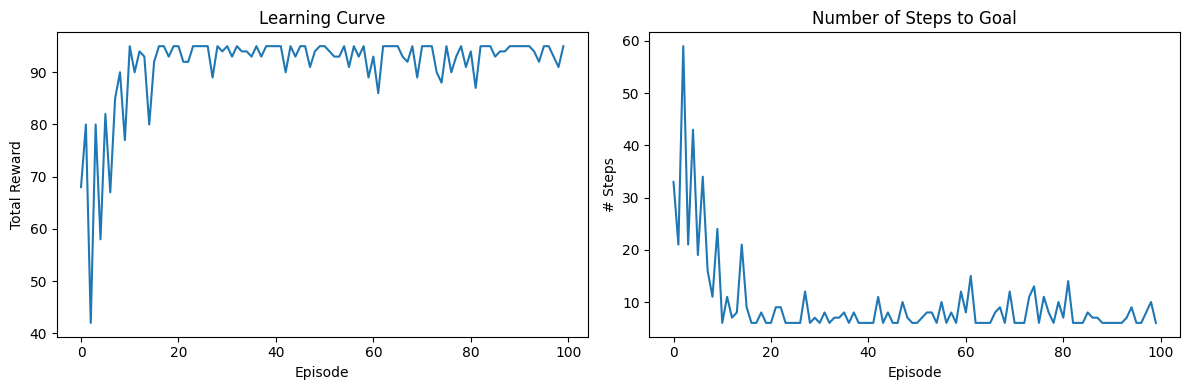

In [69]:
# Plot learning curves
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(rewards)
plt.title('Learning Curve')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.subplot(122)
plt.plot(steps)
plt.title('Number of Steps to Goal')
plt.xlabel('Episode')
plt.ylabel('# Steps')
plt.tight_layout()
plt.show()


#### Q-table after training:
Q-table is a 2D array that contains the action-values for each state-action pair. In our case:
- The Q-table will have 16 rows (states) and 4 columns (actions)
- Each cell will contain the action-value for the corresponding state-action pair

Each column in the Q-table represents an action: 
- 0: up
- 1: right
- 2: down
- 3: left
The agent will choose the action with the highest action-value for a given state.
If the values are the same, the agent will choose randomly between them.

Each row in the Q-table represents a state:
- The agent will start in the bottom-left corner (state 12)
- The goal is in the top-right corner (state 0)
- The obstacles are at positions (state 0 and state 5)
- The agent can move in four directions: up, right, down, left


In [70]:
# Print final Q-table
print("\nFinal Q-table:")
print(agent.q_table)


Final Q-table:
[[ 3.99808742e-03  3.24314144e-03  1.89248398e-03  2.69662185e-03]
 [-9.42374093e-02  4.99638024e+01 -9.10899373e-02  3.00843915e+00]
 [ 4.60347503e+01  9.99982707e+01  4.20788329e+01  1.34217573e+01]
 [ 7.57195585e-03  9.98174817e-03  8.60429948e-03  7.07486605e-03]
 [-1.16034063e+00 -1.26987616e+00 -1.14256902e+00 -1.18037130e+00]
 [ 3.39369732e-03  2.96545398e-03  8.09641474e-03  5.64371762e-03]
 [ 9.79271866e+01  1.25753039e+01  9.54127642e+00  2.42806727e+01]
 [ 7.71319272e+01  8.55113386e+00  3.95308187e-03 -9.28314060e-02]
 [-1.14985998e+00  4.22349477e+00 -1.22300813e+00 -1.06674644e+00]
 [-7.00367403e-01  5.79059456e+01  9.39319103e+00 -7.42540940e-01]
 [ 9.55588680e+01  5.45991851e+00  3.59837718e+01  1.01709646e+01]
 [ 3.39802906e+01 -9.54369310e-02 -1.83127259e-01  8.94842714e+00]
 [-1.34447832e+00  8.14353342e+01  1.58386594e+01  2.73769977e+01]
 [ 1.73660086e+01  8.79268064e+01  2.27285954e+01  1.98333748e+01]
 [ 9.24755864e+01  2.13984678e-01  3.62717182e

## 5.3 Testing the Trained Agent

Let's watch our trained agent navigate the grid. This will help us visualize what the agent has learned.

In [ ]:
# Test the trained agent
print("\nTesting trained agent:")
test_agent(agent, episodes=1)


Testing trained agent:

Episode 1
State 12 Q-values:
  UP: -1.3445
  RIGHT: 81.4353
  DOWN: 15.8387
  LEFT: 27.3770
  Best action: RIGHT
■ □ □ G
□ ■ □ □
□ □ □ □
A □ □ □

State 13 Q-values:
  UP: 17.3660
  RIGHT: 87.9268
  DOWN: 22.7286
  LEFT: 19.8334
  Best action: RIGHT
■ □ □ G
□ ■ □ □
□ □ □ □
□ A □ □

State 14 Q-values:
  UP: 92.4756
  RIGHT: 0.2140
  DOWN: 36.2717
  LEFT: 27.3435
  Best action: UP
■ □ □ G
□ ■ □ □
□ □ □ □
□ □ A □

State 10 Q-values:
  UP: 95.5589
  RIGHT: 5.4599
  DOWN: 35.9838
  LEFT: 10.1710
  Best action: UP
■ □ □ G
□ ■ □ □
□ □ A □
□ □ □ □

State 6 Q-values:
  UP: 97.9272
  RIGHT: 12.5753
  DOWN: 9.5413
  LEFT: 24.2807
  Best action: UP
■ □ □ G
□ ■ A □
□ □ □ □
□ □ □ □

State 2 Q-values:
  UP: 46.0348
  RIGHT: 99.9983
  DOWN: 42.0788
  LEFT: 13.4218
  Best action: RIGHT
■ □ A G
□ ■ □ □
□ □ □ □
□ □ □ □

Goal reached!
